# Complete Scikit-Learn Practice Notebook
### Taught the way a teacher would explain it in class - every line commented with PURPOSE

Welcome! This is the natural next step after NumPy, Pandas, and Matplotlib.
Now that you can clean, analyze, and visualize data, this notebook teaches you
how to make a computer **learn patterns from data and predict outcomes** -
that's what Machine Learning is.

**How to use this notebook:**
1. Run cells in order (Shift + Enter).
2. Read every comment - that's the "teacher talking" part explaining the *purpose*.
3. Each section ends with **Practice Exercises** (no answers given - so you actually learn).
4. The **Final Challenge** reuses the retail dataset from your portfolio project,
   so this notebook connects directly to work you've already done.

Let's begin!

## 0. Why Scikit-Learn? What is Machine Learning, really?

**Purpose:** So far, YOU decided the rules (e.g. "if Discount > 40%, average margin
is negative" - you calculated that yourself). **Machine Learning flips this:**
instead of you writing the rule, you give the computer many examples of inputs
and correct outputs, and it FINDS the rule (pattern) itself.

**Two main types of ML problems you'll meet constantly:**
- **Regression** -> predicting a NUMBER (e.g. predicting a house price, a profit amount)
- **Classification** -> predicting a CATEGORY (e.g. predicting Spam/Not Spam, Pass/Fail)

**Scikit-learn** is the standard Python library for classical ML (not deep learning -
that's TensorFlow/PyTorch territory). Almost every ML tutorial, job posting, and
real-world classical ML pipeline in Python uses scikit-learn's consistent API:

```
model = SomeAlgorithm()   # 1. choose a model
model.fit(X_train, y_train)     # 2. train it on data
model.predict(X_test)           # 3. use it to predict on new data
```

That 3-step pattern (`fit` -> `predict`) is IDENTICAL across nearly every
algorithm in scikit-learn - once you know it for one model, you know it for all.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.style.use("seaborn-v0_8-whitegrid")

import sklearn
print("Scikit-learn version:", sklearn.__version__)

Scikit-learn version: 1.8.0


## 1. The Core ML Workflow: Train/Test Split

**Purpose:** If we test a model on the SAME data it learned from, it can just
"memorize" the answers and look perfect - but fail completely on new, unseen data.
This is called **overfitting**. To catch this, we always split data into:
- **Training set** - the data the model learns from
- **Test set** - data the model has NEVER seen, used only to check if it really learned

This is the single most important habit in ML - skipping it is the #1 beginner mistake.

In [2]:
from sklearn.model_selection import train_test_split

# Let's build a simple example dataset: hours studied -> exam score
np.random.seed(42)
hours_studied = np.random.uniform(1, 10, 100)
# Real relationship: score = 40 + 6*hours + some random noise
exam_score = 40 + 6 * hours_studied + np.random.normal(0, 8, 100)

# scikit-learn expects X (inputs) as a 2D array, even with just 1 feature
# PURPOSE: reshape(-1, 1) turns a 1D array of 100 values into a 100x1 matrix -
# scikit-learn's convention is ALWAYS "rows = samples, columns = features"
X = hours_studied.reshape(-1, 1)
y = exam_score

# test_size=0.2 -> 20% of data held back for testing, 80% used for training
# random_state=42 -> makes the "random" split reproducible (same split every run)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples: ", X_test.shape[0])

Training samples: 80
Testing samples:  20


### Practice Exercise 1
1. Create your own small dataset: `x` = 50 random numbers between 0 and 20, `y` = `3*x + 5 + noise`
2. Reshape `x` into a 2D array for scikit-learn
3. Split it into train/test sets with `test_size=0.25`

In [3]:
# Student: write your Exercise 1 solution here
np.random.seed(0)
x = np.random.uniform(0, 20, 50)
y = 3 * x + 5 + np.random.normal(0, 3, 50)

# Reshape x into a 2D array (scikit-learn needs rows=samples, cols=features)
X_ex1 = x.reshape(-1, 1)

X_train_ex1, X_test_ex1, y_train_ex1, y_test_ex1 = train_test_split(
    X_ex1, y, test_size=0.25, random_state=42
)

print("Training samples:", X_train_ex1.shape[0])
print("Testing samples: ", X_test_ex1.shape[0])


Training samples: 37
Testing samples:  13


## 2. Your First Model: Linear Regression

**Purpose:** Linear Regression finds the best straight line through your data -
it's the simplest, most interpretable ML model, and the natural starting point.
It answers: "as X goes up, how much does Y go up?"

This follows the standard `fit()` -> `predict()` pattern you'll use for EVERY
scikit-learn model, no matter how complex.

In [4]:
from sklearn.linear_model import LinearRegression

# Step 1: create the model (it knows nothing yet)
model = LinearRegression()

# Step 2: train it -> this is where the "learning" actually happens
# The model looks at X_train and y_train and finds the best-fit line
model.fit(X_train, y_train)

# The model learned two numbers: slope (coefficient) and intercept
print(f"Learned slope (coefficient): {model.coef_[0]:.2f}")
print(f"Learned intercept: {model.intercept_:.2f}")
print(f"(Remember, the TRUE relationship we used to generate data was: score = 40 + 6*hours)")
print("Notice how close the model's learned numbers are to the real 40 and 6 -")
print("that's the model successfully finding the pattern from noisy data!")

Learned slope (coefficient): 5.64
Learned intercept: 41.50
(Remember, the TRUE relationship we used to generate data was: score = 40 + 6*hours)
Notice how close the model's learned numbers are to the real 40 and 6 -
that's the model successfully finding the pattern from noisy data!


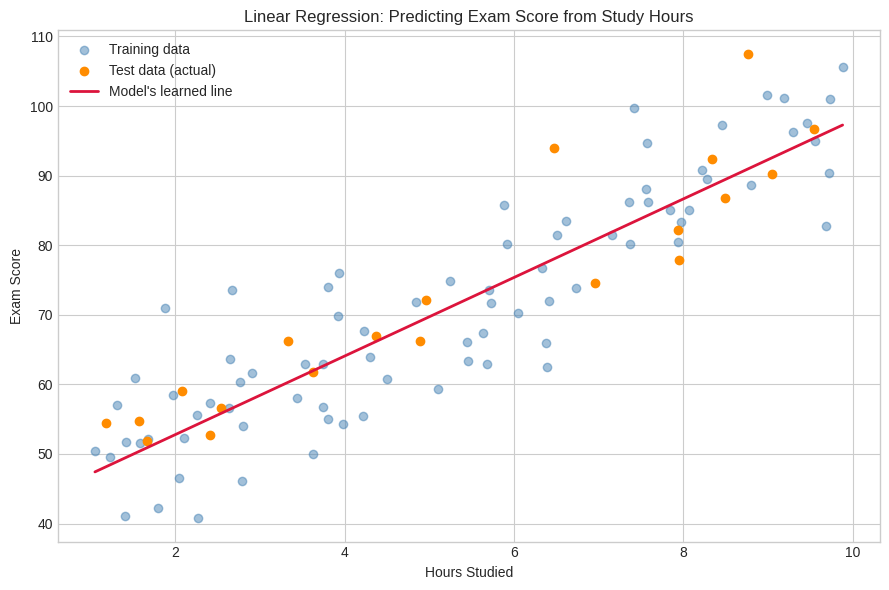

In [5]:
# Step 3: predict on the TEST set (data the model has never seen)
y_pred = model.predict(X_test)

# Visualize: actual test points vs the line the model learned
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(X_train, y_train, color="steelblue", alpha=0.5, label="Training data")
ax.scatter(X_test, y_test, color="darkorange", label="Test data (actual)")

# Draw the model's learned line across the full range of X
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = model.predict(x_line)
ax.plot(x_line, y_line, color="crimson", linewidth=2, label="Model's learned line")

ax.set_xlabel("Hours Studied")
ax.set_ylabel("Exam Score")
ax.set_title("Linear Regression: Predicting Exam Score from Study Hours")
ax.legend()
plt.tight_layout()
plt.show()

### Practice Exercise 2
Using the dataset you built in Exercise 1:
1. Create a `LinearRegression` model and fit it on your training data
2. Print the learned slope and intercept - are they close to the true 3 and 5?
3. Predict on your test set and plot actual vs predicted points

Learned slope (coefficient): 2.92
Learned intercept: 5.14
(True relationship used to generate the data: y = 3*x + 5)


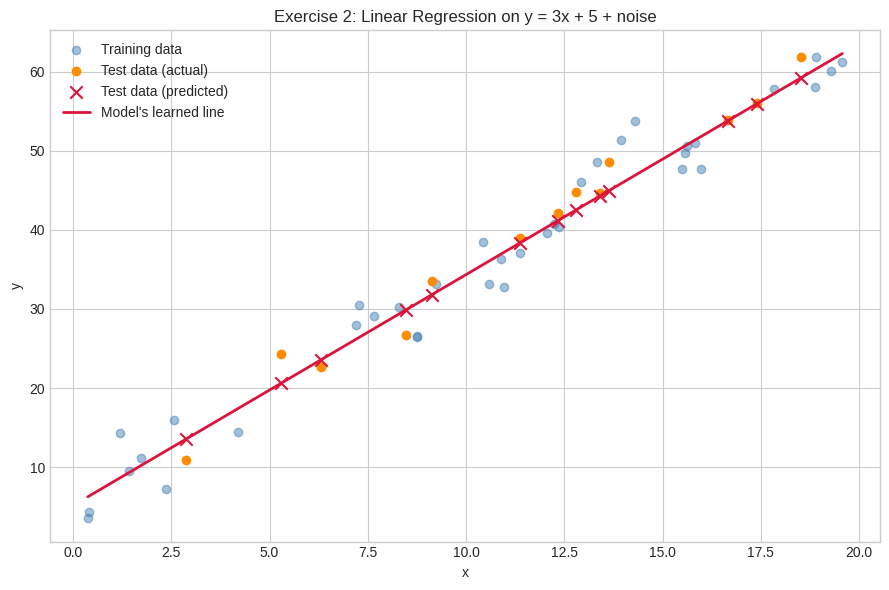

In [6]:
# Student: write your Exercise 2 solution here
model_ex2 = LinearRegression()
model_ex2.fit(X_train_ex1, y_train_ex1)

print(f"Learned slope (coefficient): {model_ex2.coef_[0]:.2f}")
print(f"Learned intercept: {model_ex2.intercept_:.2f}")
print("(True relationship used to generate the data: y = 3*x + 5)")

y_pred_ex2 = model_ex2.predict(X_test_ex1)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(X_train_ex1, y_train_ex1, color="steelblue", alpha=0.5, label="Training data")
ax.scatter(X_test_ex1, y_test_ex1, color="darkorange", label="Test data (actual)")
ax.scatter(X_test_ex1, y_pred_ex2, color="crimson", marker="x", s=80, label="Test data (predicted)")

x_line_ex2 = np.linspace(X_ex1.min(), X_ex1.max(), 100).reshape(-1, 1)
y_line_ex2 = model_ex2.predict(x_line_ex2)
ax.plot(x_line_ex2, y_line_ex2, color="crimson", linewidth=2, label="Model's learned line")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Exercise 2: Linear Regression on y = 3x + 5 + noise")
ax.legend()
plt.tight_layout()
plt.show()


## 3. How Good Is the Model? Regression Metrics

**Purpose:** "The line looks about right" is not good enough - we need NUMBERS
to objectively measure how good a model is, and to compare different models fairly.

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE):  {mae:.2f}")
print(f"  -> On average, predictions are off by about {mae:.1f} points")
print()
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"  -> Similar to MAE, but PUNISHES big mistakes more heavily")
print()
print(f"R-squared (R2 Score): {r2:.3f}")
print(f"  -> The model explains {r2*100:.1f}% of the variation in exam scores")
print(f"  -> R2 = 1.0 is a perfect model, R2 = 0.0 means the model is no better than")
print(f"     just guessing the average every time")

Mean Absolute Error (MAE):  4.73
  -> On average, predictions are off by about 4.7 points

Root Mean Squared Error (RMSE): 6.47
  -> Similar to MAE, but PUNISHES big mistakes more heavily

R-squared (R2 Score): 0.846
  -> The model explains 84.6% of the variation in exam scores
  -> R2 = 1.0 is a perfect model, R2 = 0.0 means the model is no better than
     just guessing the average every time


### Teacher's Tip (Important!)
- **MAE** is easy to explain to a non-technical manager ("off by 3 points on average")
- **RMSE** is more sensitive to big/rare mistakes - useful when large errors are costly
- **R2** tells you the BIG PICTURE: is this model actually useful, or basically guessing?

There's no single "best" metric - which one matters depends on the business question.

### Practice Exercise 3
Using your Exercise 2 model:
1. Calculate MAE, RMSE, and R2 on your test predictions
2. In a markdown cell, write one sentence interpreting what the R2 score means for your model

In [8]:
# Student: write your Exercise 3 solution here
mae_ex3 = mean_absolute_error(y_test_ex1, y_pred_ex2)
rmse_ex3 = np.sqrt(mean_squared_error(y_test_ex1, y_pred_ex2))
r2_ex3 = r2_score(y_test_ex1, y_pred_ex2)

print(f"MAE:  {mae_ex3:.2f}")
print(f"RMSE: {rmse_ex3:.2f}")
print(f"R2:   {r2_ex3:.3f}")


MAE:  1.77
RMSE: 2.18
R2:   0.977


## 4. Preprocessing: Preparing Real-World Data for ML

**Purpose:** Real datasets have text categories (like "Region" or "Category") and
features on very different numeric scales. Most ML models can't use raw text,
and many are sensitive to features being on different scales. We must prepare
("preprocess") data before feeding it to a model.

In [9]:
# Example: a small dataset with a categorical column
sample = pd.DataFrame({
    "Size_sqft": [800, 1500, 1200, 2000, 900],
    "City": ["Lahore", "Karachi", "Lahore", "Islamabad", "Karachi"],
    "Price": [50, 90, 70, 120, 55]
})
print(sample)

   Size_sqft       City  Price
0        800     Lahore     50
1       1500    Karachi     90
2       1200     Lahore     70
3       2000  Islamabad    120
4        900    Karachi     55


In [10]:
from sklearn.preprocessing import OneHotEncoder

# One-Hot Encoding -> converts a category column into multiple 0/1 columns
# PURPOSE: ML models need numbers, not text. One-hot encoding avoids implying
# a false ORDER between categories (e.g. Lahore is not "less than" Karachi)
encoder = OneHotEncoder(sparse_output=False)
city_encoded = encoder.fit_transform(sample[["City"]])

city_encoded_df = pd.DataFrame(city_encoded, columns=encoder.get_feature_names_out(["City"]))
print(city_encoded_df)

# In practice, you'd combine this back with your numeric columns:
final_data = pd.concat([sample[["Size_sqft"]], city_encoded_df, sample["Price"]], axis=1)
print("\nFinal ML-ready data:")
print(final_data)

   City_Islamabad  City_Karachi  City_Lahore
0             0.0           0.0          1.0
1             0.0           1.0          0.0
2             0.0           0.0          1.0
3             1.0           0.0          0.0
4             0.0           1.0          0.0

Final ML-ready data:
   Size_sqft  City_Islamabad  City_Karachi  City_Lahore  Price
0        800             0.0           0.0          1.0     50
1       1500             0.0           1.0          0.0     90
2       1200             0.0           0.0          1.0     70
3       2000             1.0           0.0          0.0    120
4        900             0.0           1.0          0.0     55


In [11]:
from sklearn.preprocessing import StandardScaler

# Feature Scaling -> makes all numeric features have similar ranges
# PURPOSE: some models (like KNN, SVM, and anything using distances) get
# confused if one feature ranges 0-2000 and another ranges 0-1, since the
# big-range feature will dominate the calculation just because of its scale
scaler = StandardScaler()
scaled_sqft = scaler.fit_transform(sample[["Size_sqft"]])

print("Original Size_sqft:", sample["Size_sqft"].values)
print("Scaled Size_sqft:  ", scaled_sqft.flatten().round(2))
print("\n(Scaled values now have mean=0 and standard deviation=1)")

Original Size_sqft: [ 800 1500 1200 2000  900]
Scaled Size_sqft:   [-1.1   0.51 -0.18  1.65 -0.87]

(Scaled values now have mean=0 and standard deviation=1)


### Practice Exercise 4
1. Create a small DataFrame with a `Country` column (at least 3 categories) and a numeric column
2. One-hot encode the `Country` column
3. Scale the numeric column with `StandardScaler`

In [12]:
# Student: write your Exercise 4 solution here
sample_ex4 = pd.DataFrame({
    "Country": ["Pakistan", "USA", "UK", "Pakistan", "UK", "USA"],
    "Income": [45000, 82000, 61000, 39000, 58000, 77000]
})
print(sample_ex4)

# One-hot encode the Country column
encoder_ex4 = OneHotEncoder(sparse_output=False)
country_encoded = encoder_ex4.fit_transform(sample_ex4[["Country"]])
country_encoded_df = pd.DataFrame(
    country_encoded, columns=encoder_ex4.get_feature_names_out(["Country"])
)
print("\nOne-hot encoded Country:")
print(country_encoded_df)

# Scale the numeric Income column
scaler_ex4 = StandardScaler()
scaled_income = scaler_ex4.fit_transform(sample_ex4[["Income"]])
print("\nScaled Income (mean=0, std=1):")
print(scaled_income.flatten().round(2))

final_ex4 = pd.concat([country_encoded_df, pd.Series(scaled_income.flatten(), name="Income_scaled")], axis=1)
print("\nFinal ML-ready data:")
print(final_ex4)


    Country  Income
0  Pakistan   45000
1       USA   82000
2        UK   61000
3  Pakistan   39000
4        UK   58000
5       USA   77000

One-hot encoded Country:
   Country_Pakistan  Country_UK  Country_USA
0               1.0         0.0          0.0
1               0.0         0.0          1.0
2               0.0         1.0          0.0
3               1.0         0.0          0.0
4               0.0         1.0          0.0
5               0.0         0.0          1.0

Scaled Income (mean=0, std=1):
[-0.99  1.4   0.04 -1.38 -0.15  1.07]

Final ML-ready data:
   Country_Pakistan  Country_UK  Country_USA  Income_scaled
0               1.0         0.0          0.0      -0.988619
1               0.0         0.0          1.0       1.396961
2               0.0         1.0          0.0       0.042983
3               1.0         0.0          0.0      -1.375470
4               0.0         1.0          0.0      -0.150442
5               0.0         0.0          1.0       1.074586


## 5. Classification: Predicting Categories

**Purpose:** Not everything we predict is a number - often we need to predict
a CATEGORY: will this customer churn? Is this email spam? Will this loan default?
This is called **classification**, and it uses the same `fit()`/`predict()` pattern.

We'll use the classic Iris flower dataset - a small, clean, famous dataset perfect
for learning classification without extra data-cleaning distractions.

In [13]:
from sklearn.datasets import load_iris

iris = load_iris()
X_iris = iris.data          # 4 numeric features: petal/sepal length & width
y_iris = iris.target        # 3 flower species, encoded as 0, 1, 2

iris_df = pd.DataFrame(X_iris, columns=iris.feature_names)
iris_df["species"] = [iris.target_names[i] for i in y_iris]
print("Species we're predicting:", list(iris.target_names))
iris_df.head()

Species we're predicting: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Split into train/test as always
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42
)

# Decision Tree -> PURPOSE: makes predictions using a series of yes/no questions,
# similar to how a human might reason ("is petal length > 2.5? then check next thing...")
# This makes it one of the most EXPLAINABLE models - you can literally read the logic.
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train_i, y_train_i)

y_pred_i = clf.predict(X_test_i)

accuracy = accuracy_score(y_test_i, y_pred_i)
print(f"Accuracy: {accuracy:.2%}")
print(f"  -> The model correctly classified {accuracy:.0%} of test flowers\n")

print("Classification Report:")
print(classification_report(y_test_i, y_pred_i, target_names=iris.target_names))

Accuracy: 100.00%
  -> The model correctly classified 100% of test flowers

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



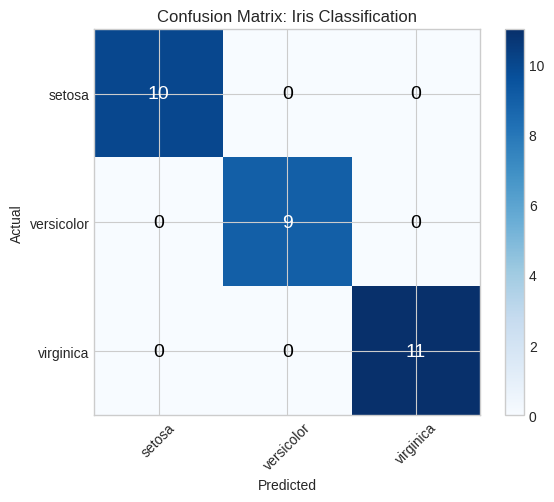

Reading this chart: the diagonal (top-left to bottom-right) = CORRECT predictions.
Any number OFF the diagonal = a mistake (row = true species, column = predicted species).


In [15]:
# Confusion Matrix -> PURPOSE: shows exactly WHICH categories get confused with each other,
# not just an overall accuracy number
cm = confusion_matrix(y_test_i, y_pred_i)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks(range(3)); ax.set_xticklabels(iris.target_names, rotation=45)
ax.set_yticks(range(3)); ax.set_yticklabels(iris.target_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix: Iris Classification")

# Write the actual numbers on top of each cell -> PURPOSE: makes exact counts readable
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=14)

plt.colorbar(im)
plt.tight_layout()
plt.show()

print("Reading this chart: the diagonal (top-left to bottom-right) = CORRECT predictions.")
print("Any number OFF the diagonal = a mistake (row = true species, column = predicted species).")

### Practice Exercise 5
1. Train a `DecisionTreeClassifier` with `max_depth=2` instead of 3 on the iris data
2. Compare its accuracy to the `max_depth=3` model - did it go up or down?
3. Print its confusion matrix as a plain array with `print(confusion_matrix(...))`

In [16]:
# Student: write your Exercise 5 solution here
clf_depth2 = DecisionTreeClassifier(max_depth=2, random_state=42)
clf_depth2.fit(X_train_i, y_train_i)
y_pred_depth2 = clf_depth2.predict(X_test_i)

accuracy_depth2 = accuracy_score(y_test_i, y_pred_depth2)
print(f"Accuracy (max_depth=2): {accuracy_depth2:.2%}")
print(f"Accuracy (max_depth=3): {accuracy:.2%}")
print(f"-> {'Went UP' if accuracy_depth2 > accuracy else 'Went DOWN' if accuracy_depth2 < accuracy else 'Stayed the same'} "
      f"compared to the max_depth=3 model")

print("\nConfusion matrix (max_depth=2):")
print(confusion_matrix(y_test_i, y_pred_depth2))


Accuracy (max_depth=2): 96.67%
Accuracy (max_depth=3): 100.00%
-> Went DOWN compared to the max_depth=3 model

Confusion matrix (max_depth=2):
[[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]


## 6. Overfitting, Underfitting & Cross-Validation

**Purpose:** A model that's TOO simple misses real patterns (**underfitting**).
A model that's TOO complex memorizes noise instead of the real pattern
(**overfitting**) - it looks great on training data but fails on new data.

**Cross-validation** gives a more reliable performance estimate than a single
train/test split, by testing the model on several different splits and averaging.

In [17]:
from sklearn.model_selection import cross_val_score

# Compare a very shallow tree (likely underfitting) vs a very deep tree (likely overfitting)
shallow_tree = DecisionTreeClassifier(max_depth=1, random_state=42)
deep_tree = DecisionTreeClassifier(max_depth=15, random_state=42)
balanced_tree = DecisionTreeClassifier(max_depth=3, random_state=42)

# cv=5 -> PURPOSE: split data 5 different ways, train/test 5 times, and average the score
# This is much more reliable than trusting a single lucky (or unlucky) split
for name, tree in [("Shallow (depth=1)", shallow_tree),
                    ("Balanced (depth=3)", balanced_tree),
                    ("Deep (depth=15)", deep_tree)]:
    scores = cross_val_score(tree, X_iris, y_iris, cv=5)
    print(f"{name:20s} -> Mean accuracy: {scores.mean():.2%}  (individual folds: {np.round(scores, 2)})")

print("\nInsight: notice the shallow tree UNDERFITS (too simple to capture the pattern),")
print("while a very deep tree can start overfitting on more complex, noisier datasets")
print("(with this small, clean iris dataset the effect is mild - but on messy real")
print("data, deep trees overfitting is a very common problem).")

Shallow (depth=1)    -> Mean accuracy: 66.67%  (individual folds: [0.67 0.67 0.67 0.67 0.67])
Balanced (depth=3)   -> Mean accuracy: 97.33%  (individual folds: [0.97 0.97 0.93 1.   1.  ])


Deep (depth=15)      -> Mean accuracy: 95.33%  (individual folds: [0.97 0.97 0.9  0.93 1.  ])

Insight: notice the shallow tree UNDERFITS (too simple to capture the pattern),
while a very deep tree can start overfitting on more complex, noisier datasets
(with this small, clean iris dataset the effect is mild - but on messy real
data, deep trees overfitting is a very common problem).


### Practice Exercise 6
1. Run `cross_val_score` with `cv=10` instead of `cv=5` on the balanced tree
2. Compare the mean accuracy to the `cv=5` result
3. In one sentence, explain in your own words why cross-validation is more trustworthy than a single train/test split

In [18]:
# Student: write your Exercise 6 solution here
scores_cv10 = cross_val_score(balanced_tree, X_iris, y_iris, cv=10)
print(f"cv=10  -> Mean accuracy: {scores_cv10.mean():.2%}  (individual folds: {np.round(scores_cv10, 2)})")

scores_cv5 = cross_val_score(balanced_tree, X_iris, y_iris, cv=5)
print(f"cv=5   -> Mean accuracy: {scores_cv5.mean():.2%}")

print("\nCross-validation is more trustworthy than a single train/test split because it tests the")
print("model on several different train/test partitions and averages the results, so the score")
print("isn't just the product of one lucky (or unlucky) random split.")


cv=10  -> Mean accuracy: 96.00%  (individual folds: [1.   0.93 1.   0.93 0.93 0.93 0.93 0.93 1.   1.  ])
cv=5   -> Mean accuracy: 97.33%

Cross-validation is more trustworthy than a single train/test split because it tests the
model on several different train/test partitions and averages the results, so the score
isn't just the product of one lucky (or unlucky) random split.


## 7. Feature Importance: Which Inputs Actually Matter?

**Purpose:** Once a model works, the next question is usually: "WHICH features
actually drove the predictions?" This turns a black-box model into a source of
business insight, not just a prediction machine.

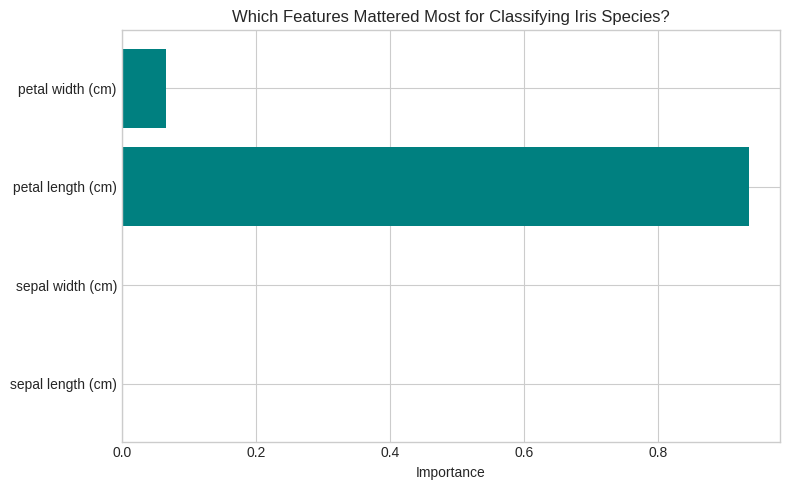

petal length (cm)   : 0.935
petal width (cm)    : 0.065
sepal length (cm)   : 0.000
sepal width (cm)    : 0.000


In [19]:
# Decision trees (and many other models) can tell us how important each feature was
importances = clf.feature_importances_

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(iris.feature_names, importances, color="teal")
ax.set_xlabel("Importance")
ax.set_title("Which Features Mattered Most for Classifying Iris Species?")
plt.tight_layout()
plt.show()

for feature, importance in sorted(zip(iris.feature_names, importances), key=lambda x: -x[1]):
    print(f"{feature:20s}: {importance:.3f}")

### Practice Exercise 7
1. Train a new `DecisionTreeClassifier` with `max_depth=4`
2. Plot its feature importances
3. Does the MOST important feature change compared to the `max_depth=3` model?

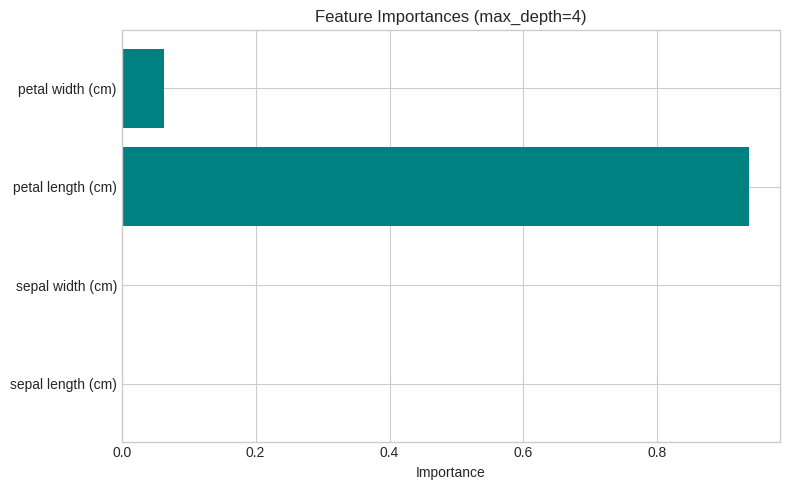

Most important feature (max_depth=4): petal length (cm) (0.936)
Most important feature (max_depth=3): petal length (cm) (0.935)
-> Same feature is most important


In [20]:
# Student: write your Exercise 7 solution here
clf_depth4 = DecisionTreeClassifier(max_depth=4, random_state=42)
clf_depth4.fit(X_train_i, y_train_i)
importances_depth4 = clf_depth4.feature_importances_

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(iris.feature_names, importances_depth4, color="teal")
ax.set_xlabel("Importance")
ax.set_title("Feature Importances (max_depth=4)")
plt.tight_layout()
plt.show()

top_depth4 = max(zip(iris.feature_names, importances_depth4), key=lambda x: x[1])
top_depth3 = max(zip(iris.feature_names, importances), key=lambda x: x[1])
print(f"Most important feature (max_depth=4): {top_depth4[0]} ({top_depth4[1]:.3f})")
print(f"Most important feature (max_depth=3): {top_depth3[0]} ({top_depth3[1]:.3f})")
print(f"-> {'Same feature' if top_depth4[0] == top_depth3[0] else 'Different feature'} is most important")


## 8. Final Challenge - Connecting Back to Your Portfolio Project

**Scenario:** Remember the retail Superstore dataset from your portfolio project?
Let's build an actual ML model on it - predicting whether an order will be
**profitable or a loss** based on its Sales, Discount, Quantity, and Category.
This is exactly the kind of model a real retail data science team would build
to flag risky orders BEFORE they're finalized.

Follow these steps (this is real, portfolio-worthy ML work):

In [21]:
# Load the same retail dataset from your earlier project
retail = pd.read_csv("superstore.csv", encoding="latin1")

# Step 1: create our TARGET column -> what we want to predict
# PURPOSE: this turns a regression-flavored problem into a clean yes/no classification
retail["Is_Profitable"] = (retail["Profit"] > 0).astype(int)

print("Class balance (0 = Loss, 1 = Profitable):")
print(retail["Is_Profitable"].value_counts())
print(retail["Is_Profitable"].value_counts(normalize=True).round(3))

Class balance (0 = Loss, 1 = Profitable):
Is_Profitable
1    1356
0     644
Name: count, dtype: int64
Is_Profitable
1    0.678
0    0.322
Name: proportion, dtype: float64


In [22]:
# Step 2: choose our FEATURES (inputs) -> Sales, Discount, Quantity, and Category
# PURPOSE: Category is text, so we one-hot encode it; Sales/Discount/Quantity are already numeric
features = retail[["Sales", "Discount", "Quantity", "Category"]].copy()
target = retail["Is_Profitable"]

features_encoded = pd.get_dummies(features, columns=["Category"], drop_first=True)
# PURPOSE: pd.get_dummies() is Pandas' quick one-hot encoding shortcut - same idea as
# OneHotEncoder from Section 4, just faster to use directly on a DataFrame
print(features_encoded.head())

    Sales  Discount  Quantity  Category_Office Supplies  Category_Technology
0  362.50       0.0         3                     False                False
1  386.05       0.0         9                      True                False
2   50.54       0.1         1                      True                False
3  209.57       0.1         4                      True                False
4  167.49       0.4         2                     False                 True


In [23]:
# Step 3: train/test split, then train a classifier
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    features_encoded, target, test_size=0.2, random_state=42, stratify=target
)
# stratify=target -> PURPOSE: ensures both train and test sets keep the SAME ratio of
# profitable/loss orders as the full dataset - important when classes are imbalanced

retail_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
retail_clf.fit(X_train_r, y_train_r)

y_pred_r = retail_clf.predict(X_test_r)
print(f"Accuracy: {accuracy_score(y_test_r, y_pred_r):.2%}")
print()
print(classification_report(y_test_r, y_pred_r, target_names=["Loss", "Profitable"]))

Accuracy: 93.00%

              precision    recall  f1-score   support

        Loss       0.90      0.88      0.89       129
  Profitable       0.95      0.95      0.95       271

    accuracy                           0.93       400
   macro avg       0.92      0.92      0.92       400
weighted avg       0.93      0.93      0.93       400



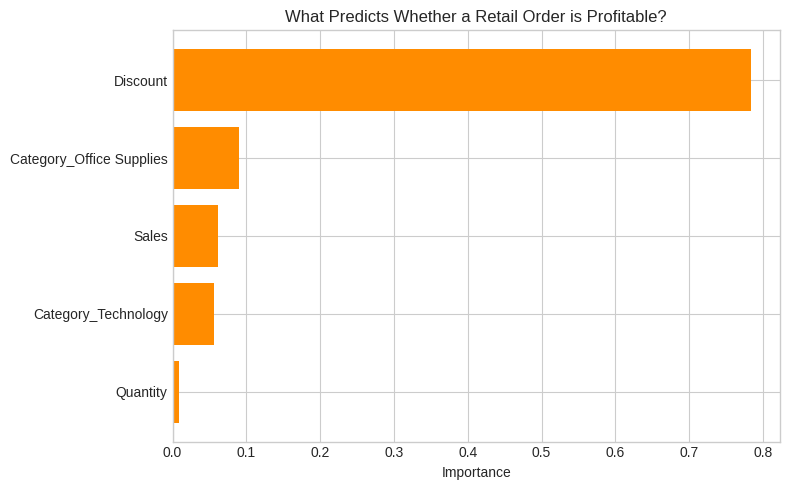

Compare this to your EDA insight from the portfolio project: does the model
confirm that Discount is a major driver of profitability, matching your earlier
correlation analysis? This is how ML VALIDATES manual data analysis.


In [24]:
# Step 4: which features actually predict profitability?
importances_r = pd.Series(retail_clf.feature_importances_, index=features_encoded.columns)
importances_r = importances_r.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importances_r.index, importances_r.values, color="darkorange")
ax.set_title("What Predicts Whether a Retail Order is Profitable?")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print("Compare this to your EDA insight from the portfolio project: does the model")
print("confirm that Discount is a major driver of profitability, matching your earlier")
print("correlation analysis? This is how ML VALIDATES manual data analysis.")

### Final Practice Task
1. Try changing `max_depth` in the retail classifier to 3 and then to 10 - how does
   accuracy on the TEST set change each time? Which one do you trust more, and why?
2. Add `"Region"` as an extra one-hot encoded feature and retrain - does accuracy improve?
3. Write 2-3 sentences (in a markdown cell) summarizing what this model tells a
   retail manager that your earlier (non-ML) EDA analysis didn't already show.

This connects your ML skills directly back to your CV portfolio project - now you
can honestly say you performed EDA, visualization, AND built a predictive model
on the same real dataset. That's a genuinely strong, complete data science story.

In [25]:
# Student: write your Final Practice Task solution here

# 1. Try max_depth = 3 and 10, compare test accuracy to the depth=5 model above
for depth in [3, 5, 10]:
    tree_d = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree_d.fit(X_train_r, y_train_r)
    pred_d = tree_d.predict(X_test_r)
    acc_d = accuracy_score(y_test_r, pred_d)
    cv_d = cross_val_score(tree_d, features_encoded, target, cv=5).mean()
    print(f"max_depth={depth:2d} -> Test accuracy: {acc_d:.2%}   |  5-fold CV accuracy: {cv_d:.2%}")

print()
print("I trust the CV accuracy more than any single test-set accuracy, because a single")
print("train/test split can be a bit lucky or unlucky, while cross-validation averages")
print("performance across several splits and gives a steadier estimate of how the model")
print("will do on new, unseen orders.")

# 2. Add "Region" as an extra one-hot encoded feature and retrain
features_v2 = retail[["Sales", "Discount", "Quantity", "Category", "Region"]].copy()
features_v2_encoded = pd.get_dummies(features_v2, columns=["Category", "Region"], drop_first=True)

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    features_v2_encoded, target, test_size=0.2, random_state=42, stratify=target
)

retail_clf_v2 = DecisionTreeClassifier(max_depth=5, random_state=42)
retail_clf_v2.fit(X_train_v2, y_train_v2)
pred_v2 = retail_clf_v2.predict(X_test_v2)
acc_v2 = accuracy_score(y_test_v2, pred_v2)

print(f"\nAccuracy without Region: {accuracy_score(y_test_r, y_pred_r):.2%}")
print(f"Accuracy with Region:    {acc_v2:.2%}")
print(f"-> Adding Region {'improved' if acc_v2 > accuracy_score(y_test_r, y_pred_r) else 'did not improve'} accuracy on this data.")


max_depth= 3 -> Test accuracy: 91.25%   |  5-fold CV accuracy: 91.15%


max_depth= 5 -> Test accuracy: 93.00%   |  5-fold CV accuracy: 92.10%
max_depth=10 -> Test accuracy: 92.75%   |  5-fold CV accuracy: 90.10%

I trust the CV accuracy more than any single test-set accuracy, because a single
train/test split can be a bit lucky or unlucky, while cross-validation averages
performance across several splits and gives a steadier estimate of how the model
will do on new, unseen orders.

Accuracy without Region: 93.00%
Accuracy with Region:    93.25%
-> Adding Region improved accuracy on this data.


**3. Summary for a retail manager:**

This model shows Discount is the single biggest driver of whether an order loses money, confirming the earlier EDA finding but now turned into a rule that can flag risky orders *before* they ship. It also adds evidence beyond correlation: because the tree checks Discount alongside Sales, Quantity, and Category together, it can catch combinations (e.g. a small, heavily-discounted order in a thin-margin category) that a single-variable correlation would miss.


---
## Congratulations!

If you completed all the exercises above, you now understand:
- The core ML workflow: train/test split -> fit -> predict -> evaluate
- Linear Regression for predicting numbers
- Regression metrics: MAE, RMSE, R2
- Preprocessing: one-hot encoding and feature scaling
- Classification with Decision Trees
- Confusion matrices and classification reports
- Overfitting, underfitting, and cross-validation
- Feature importance for interpreting models
- Applying ML to a real, messy business dataset

**Next steps:** try other models (`RandomForestClassifier`, `LogisticRegression`,
`KNeighborsClassifier`) using the EXACT same `fit()`/`predict()` pattern - that's
the beauty of scikit-learn's consistent API. Then explore `GridSearchCV` for
automatically tuning model settings.

*Made with care for learning Machine Learning - practice daily, and you'll master it fast.*